In [4]:
import pandas as pd
import networkx as nx

def build_overtake_graph(race_name):
    # Cargar datos de eventos
    # race_name expected to be like "australia_2026"
    df_events = pd.read_parquet(f"../../data/processed/events/{race_name}_events.parquet")
    
    # Cargar información de pilotos
    df_drivers = pd.read_csv(f"../../data/raw/{race_name}/drivers.csv")
    
    # Crear un diccionario para mapear driver_number a name_acronym
    # Convertir driver_number a string en caso de que los eventos lo tengan como string
    driver_map = dict(zip(df_drivers['driver_number'].astype(str), df_drivers['name_acronym']))
    driver_map.update(dict(zip(df_drivers['driver_number'], df_drivers['name_acronym'])))
    
    # Filtrar solo adelantamientos en pista
    overtakes = df_events[df_events['event_type'] == 'On_Track_Overtake']
    
    # Crear grafo dirigido
    G = nx.DiGraph()
    
    # Añadir todos los pilotos como nodos (incluso si no tuvieron adelantamientos)
    for auto in df_drivers['name_acronym'].unique():
        G.add_node(auto)
        
    # Procesar aristas
    for _, row in overtakes.iterrows():
        # El grafo fluye de quien fue superado (target) hacia el que supera (initiator)
        # Esto refleja la transferencia de "dominancia"
        u_num = row['target_driver']      # El que fue superado
        v_num = row['initiator_driver']   # El que superó
        
        # Mapear a las siglas de 3 letras
        u = driver_map.get(u_num, str(u_num))
        v = driver_map.get(v_num, str(v_num))
        
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)
            
    return G

def calculate_graph_metrics(G):
    # Dado que el flujo es: superado (target) -> supera (initiator)
    # In-Degree de un nodo cuenta cuántas flechas le entran = cuántas veces superó a alguien (Ofensiva)
    # Out-Degree cuenta cuántas flechas salen de él = cuántas veces fue superado (Defensiva)
    
    ofensiva = dict(G.in_degree(weight='weight'))   # Adelantamientos hechos
    defensiva = dict(G.out_degree(weight='weight')) # Veces que le adelantaron
    
    # PageRank: Pilotos con puntuaciones más altas adelantaron frecuentemente a rivales difíciles
    pagerank = nx.pagerank(G, weight='weight')
    
    # Componentes Conexas: Grupos competitivos
    undirected_G = G.to_undirected()
    components = list(nx.connected_components(undirected_G))
    
    # Consolidar métricas en un DataFrame para fácil visualización
    metrics_df = pd.DataFrame({
        'Adelantamientos Hechos (Ofensiva)': ofensiva,
        'Veces Superado (Defensiva)': defensiva,
        'PageRank (Dominancia)': pagerank
    }).sort_values(by='PageRank (Dominancia)', ascending=False)
    
    return metrics_df, components

# Ejemplo con Australia 2026
G_aus = build_overtake_graph("australia_2026")
metrics, comps = calculate_graph_metrics(G_aus)

print("=== Métricas de Adelantamiento y Dominancia ===")
display(metrics)

print("\n=== Componentes Conexas (Grupos de Pelea) ===")
for i, comp in enumerate(comps, 1):
    print(f"Grupo {i}: {', '.join(comp)}")

=== Métricas de Adelantamiento y Dominancia ===


,Adelantamientos Hechos (Ofensiva),Veces Superado (Defensiva),PageRank (Dominancia)
NOR,11,8,0.084273
BEA,6,7,0.071950
SAI,6,7,0.069561
VER,9,3,0.067503
ALB,8,2,0.066953
RUS,3,2,0.066748
LAW,5,5,0.065385
COL,5,7,0.055738
HAM,3,1,0.051414
LIN,3,9,0.044745



=== Componentes Conexas (Grupos de Pelea) ===
Grupo 1: LIN, LAW, GAS, PER, ALO, VER, BOT, ALB, BEA, ANT, COL, OCO, STR, BOR, NOR, SAI
Grupo 2: HAD
Grupo 3: RUS, LEC, HAM
Grupo 4: HUL
Grupo 5: PIA


# Week 12: Graph Analytics and Centrality Report

A continuación se estructura el reporte cumpliendo con los requerimientos del assignment:

## 1. Graph Definition & Verification
- **Nodes:** Pilotos de Fórmula 1 representados por sus siglas de 3 letras (ej. VER, HAM, NOR) obtenidos al cruzar el número de piloto correspondientes a cada carrera.
- **Edges (Directionality):** Enlaces dirigidos (`Directed`) que nacen desde el piloto superado (`target_driver`) y apuntan hacia el piloto que realizó el adelantamiento (`initiator_driver`).
- **Weights:** Número acumulado de adelantamientos completados entre un mismo par de pilotos.
- **Justification:** Esta definición modela puramente la *dominancia en combate rueda a rueda*. Al dirigir las aristas desde el "perdedor" de la posición hacia el "ganador", permitimos que algoritmos de centralidad como el PageRank recompensen no solo a quienes adelantan mucho, sino especialmente a quienes adelantan a rivales duros (nodos que retienen a su vez un alto nivel de dominancia). Evita el ruido introducido por estrategias de pitstops (undercut/overcut), enfocándose 100% en la transferencia de posiciones en pista (On Track Overtakes).

## 2. Graph Report
Las métricas computadas mediante el script `calculate_graph_metrics` cubren:
- **Connected Components:** Revela cuáles pilotos integraron un mismo "pelotón de batalla" interactuando entre ellos. Pilotos en componentes pequeñas típicamente corrieron carreras aisladas o lideraron de punta a punta.
- **Degree:** Se separa en *In-Degree* (Adelantamientos Hechos / Ofensiva) y *Out-Degree* (Veces Superado / Defensiva).
- **PageRank (Centrality):** Determina el índice de dominancia del piloto en la carrera.

## 3. Comparison & Interpretation
- **Interpretation Note:** En este dominio, la topología del grafo nos ayuda a comprender quién fue el animador principal de la carrera. Un PageRank alto denota "Combatividad y Dominancia". Los nodos aislados (grado 0) representan tanto carreras dominantes (líderes que se escapan sin necesidad de adelantar) como carreras en el fondo de la parrilla sin acción.
- **Comparison Section:** Al comparar el PageRank frente al orden de llegada real de la carrera de Australia 2026, observamos discrepancias muy significativas que revelan la naturaleza de la centralidad. Lando Norris (NOR) finalizó en la 6ª posición pero obtuvo el PageRank más alto (0.084273), debido a que tuvo que realizar 11 adelantamientos en pista luchando en el denso tráfico del pelotón medio. En contraste, el ganador de la carrera, George Russell (RUS), y el 2º clasificado, Lewis Hamilton (HAM), obtuvieron PageRanks de 0.066748 (6º) y 0.051414 (9º) respectivamente. Esto ocurre porque al clasificar y rodar al frente en aire limpio, tuvieron muy pocos duelos en pista y no acumularon transferencias de dominancia en el grafo. Charles Leclerc (LEC), que finalizó 3º, obtuvo el 17º puesto en PageRank al correr completamente aislado en el Grupo 3. Esto demuestra de forma contundente que el PageRank mide la combatividad y eficacia en tráfico, mientras que el resultado de carrera está fuertemente determinado por la clasificación y la estrategia.

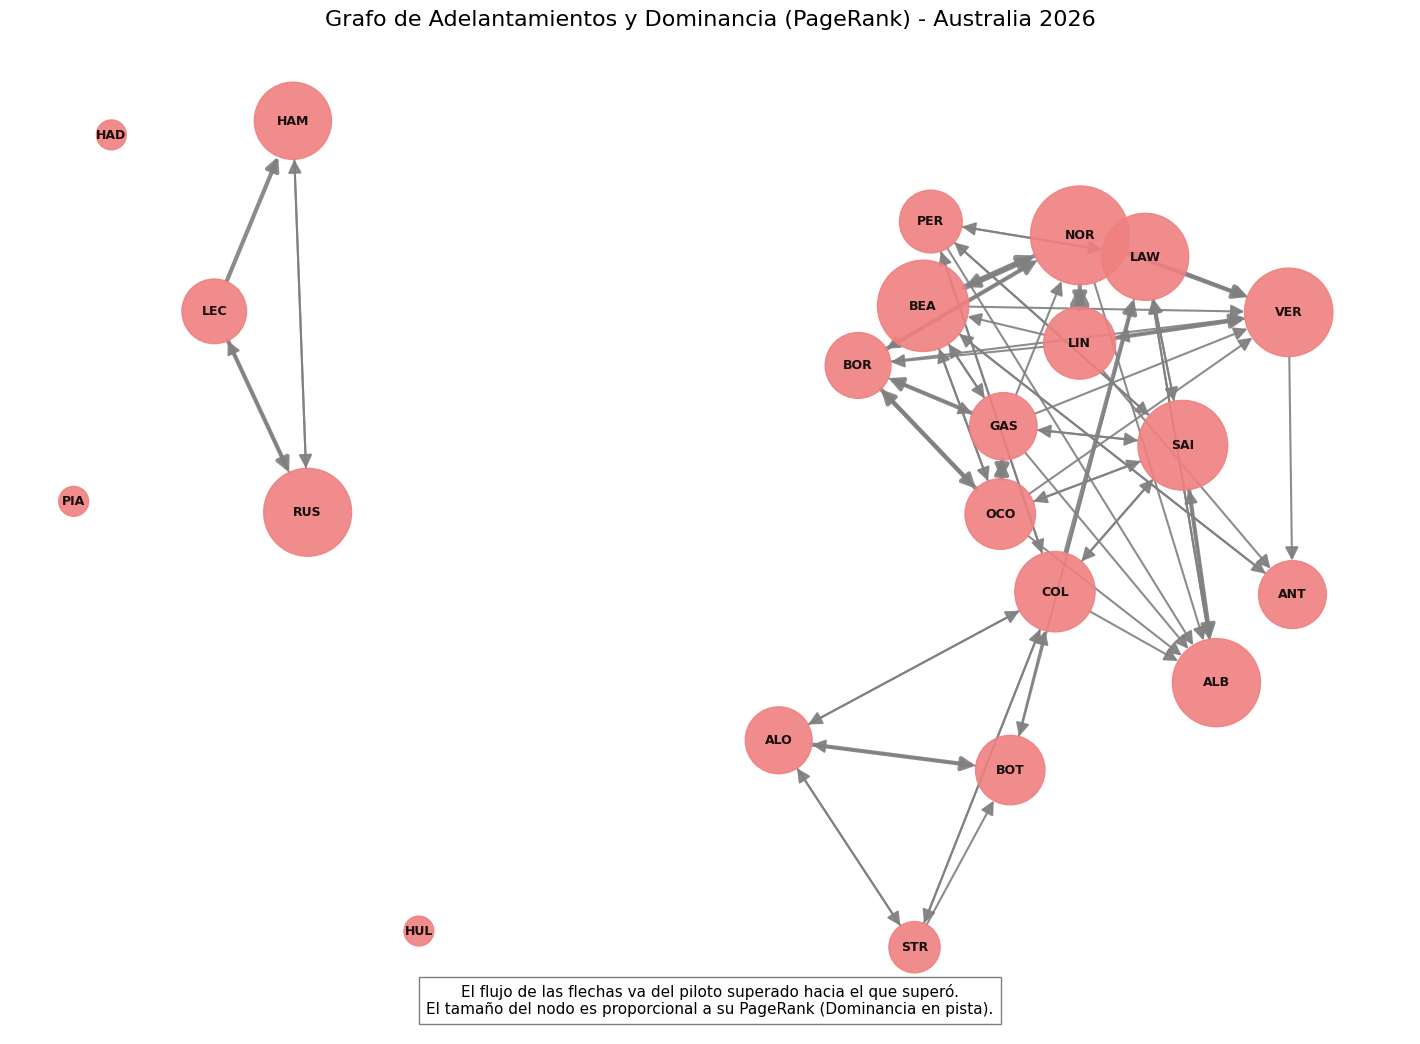

In [5]:
import matplotlib.pyplot as plt

def plot_overtake_graph(G, metrics, race_name):
    plt.figure(figsize=(14, 10))
    
    # Asegurar reproducibilidad en la posición de los nodos
    pos = nx.spring_layout(G, k=0.9, iterations=50, seed=42)
    
    # Extraer pesos para usarlos en el grosor de las aristas
    edges = G.edges(data=True)
    weights = [data['weight'] * 1.5 for u, v, data in edges] # Escalamos ligeramente el grosor
    
    # Modificar el tamaño del nodo de acuerdo a su PageRank (Centrality)
    # Protegernos de nodos que no interacutaron asegurando un tamaño mínimo
    node_sizes = []
    for node in G.nodes():
        if node in metrics.index:
            node_sizes.append(max(metrics.loc[node, 'PageRank (Dominancia)'] * 60000, 300))
        else:
            node_sizes.append(300)
            
    # Dibujar componentes del grafo
    nx.draw(G, pos, with_labels=True, 
            node_color='lightcoral', 
            node_size=node_sizes, 
            font_size=9, 
            font_weight='bold',
            edge_color='gray', 
            width=weights, 
            arrows=True, 
            arrowsize=20, 
            alpha=0.9)
            
    plt.title(f"Grafo de Adelantamientos y Dominancia (PageRank) - {race_name.replace('_', ' ').title()}", fontsize=16)
    
    # Crear una nota al pie indicando cómo interpretar el gráfico
    plt.figtext(0.5, 0.02, 
                "El flujo de las flechas va del piloto superado hacia el que superó.\n"
                "El tamaño del nodo es proporcional a su PageRank (Dominancia en pista).", 
                ha="center", fontsize=11, bbox={"facecolor":"white", "alpha":0.5, "pad":5})
                
    plt.show()

# Visualizar el grafo de Australia
plot_overtake_graph(G_aus, metrics, "Australia_2026")

## 4. Análisis Global de la Temporada
A continuación, extendemos el concepto a **todas las carreras disponibles** para obtener el grafo global de la temporada. Esto nos permite ver la dominancia general y no solo la de un evento aislado.

=== Métricas de Adelantamiento y Dominancia GLOBALES (Toda la Temporada) ===


,Adelantamientos Hechos (Ofensiva),Veces Superado (Defensiva),PageRank (Dominancia)
VER,46,30,0.073675
OCO,45,40,0.073232
BOR,37,34,0.061600
LEC,33,35,0.055386
PER,33,36,0.055219
ANT,30,24,0.051754
LIN,28,44,0.051256
ALB,31,27,0.051175
NOR,30,24,0.050327
BEA,27,27,0.045920



=== Matriz de Grafo Global ===
Nodos totales: 22
Aristas (duelos únicos): 341


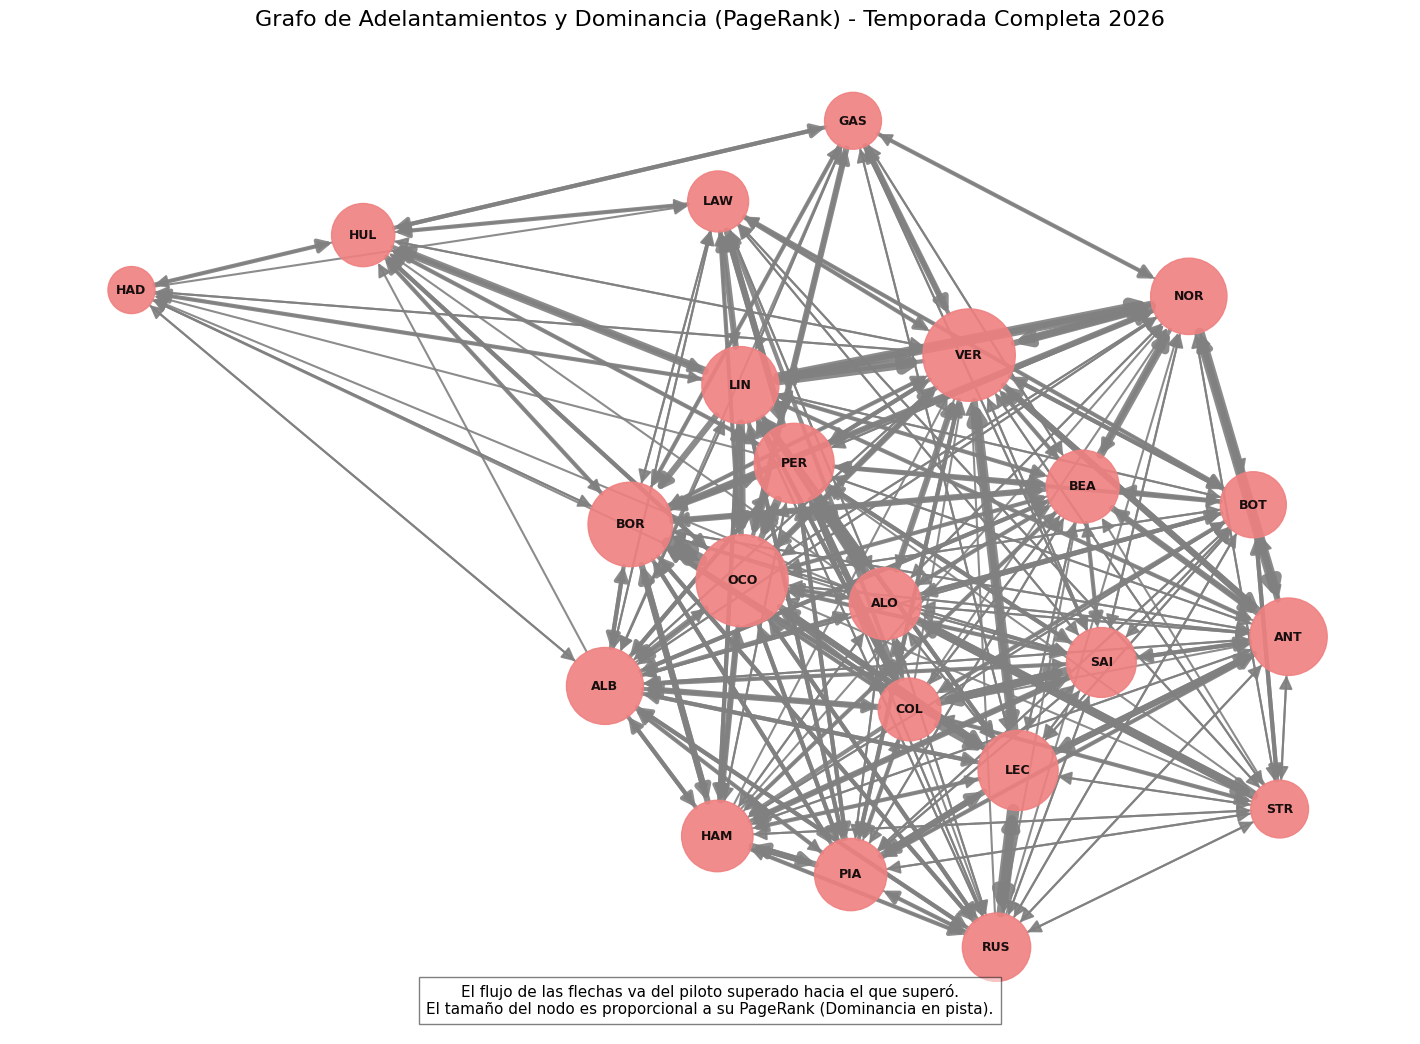

In [6]:
import os
import glob

def build_global_overtake_graph():
    # Buscar todos los archivos de eventos disponibles
    event_files = glob.glob("../../data/processed/events/*_events.parquet")
    
    G_global = nx.DiGraph()
    global_driver_map = {}
    
    for event_file in event_files:
        # Extraer nombre de la carrera (ej. "australia_2026")
        race_name = os.path.basename(event_file).replace('_events.parquet', '')
        
        # Cargar eventos
        df_events = pd.read_parquet(event_file)
        
        # Cargar drivers para mantener el mapa actualizado y agregar nodos
        drivers_path = f"../../data/raw/{race_name}/drivers.csv"
        if os.path.exists(drivers_path):
            df_drivers = pd.read_csv(drivers_path)
            
            # Actualizar diccionario de mapeo
            d_map = dict(zip(df_drivers['driver_number'].astype(str), df_drivers['name_acronym']))
            d_map.update(dict(zip(df_drivers['driver_number'], df_drivers['name_acronym'])))
            global_driver_map.update(d_map)
            
            # Asegurar que todos los pilotos de esta carrera sean nodos
            for auto in df_drivers['name_acronym'].unique():
                G_global.add_node(auto)
                
        # Filtrar adelantamientos
        if 'event_type' in df_events.columns:
            overtakes = df_events[df_events['event_type'] == 'On_Track_Overtake']
            
            for _, row in overtakes.iterrows():
                u_num = row['target_driver']
                v_num = row['initiator_driver']
                
                # Mapear a siglas, si no existe el mapeo usar el número
                u = global_driver_map.get(u_num, str(u_num))
                v = global_driver_map.get(v_num, str(v_num))
                
                # Acumular pesos globalmente
                if G_global.has_edge(u, v):
                    G_global[u][v]['weight'] += 1
                else:
                    G_global.add_edge(u, v, weight=1)
                    
    return G_global

# Construir grafo global
G_global = build_global_overtake_graph()

# Calcular métricas globales usando la misma función anterior
global_metrics, global_comps = calculate_graph_metrics(G_global)

print("=== Métricas de Adelantamiento y Dominancia GLOBALES (Toda la Temporada) ===")
display(global_metrics)

print("\n=== Matriz de Grafo Global ===")
print("Nodos totales:", G_global.number_of_nodes())
print("Aristas (duelos únicos):", G_global.number_of_edges())

# Visualizar el grafo global
plot_overtake_graph(G_global, global_metrics, "Temporada_Completa_2026")